Spurs Offensive Deviation Variable: 13.6482
Spurs Defensive Deviation Variable: 6.2555
Knicks Defensive Deviation Variable: 13.6482
Knicks Offfensive Deviation Variable: 6.2555
      MONTE CARLO SIMULATION RESULTS (1000 RUNS)     
Spurs Win Probability: 47.70%
Knicks Win Probability: 52.30%
--------------------------------------------------
Projected Point Spread: Knicks -1.5
Projected Game Total (Over/Under): 217.9


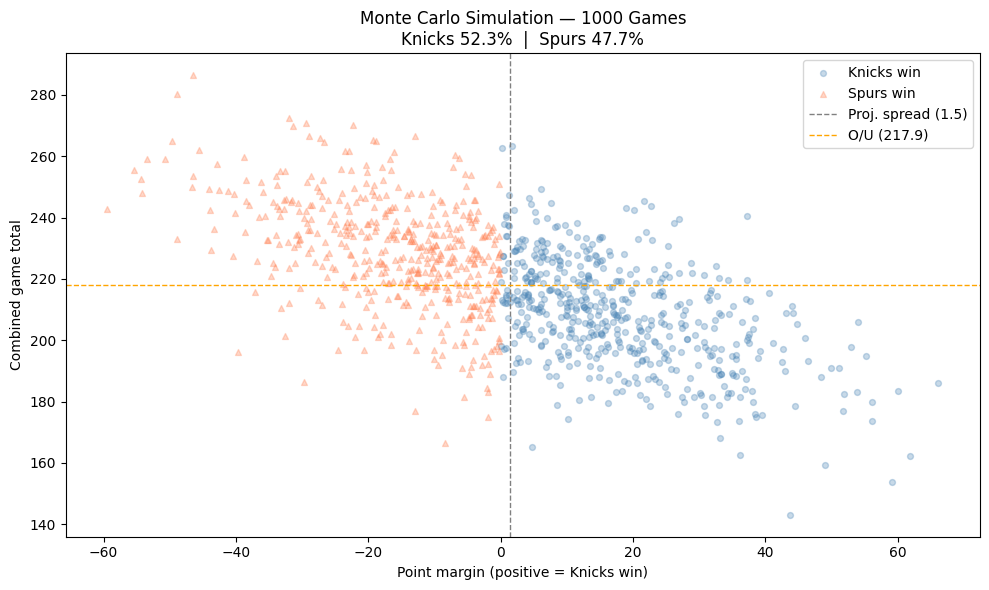

In [192]:
# NBA Monte Carlo Simulator

"""Predicts NBA playoff game outcomes using Monte Carlo simulation
with strength-of-schedule adjustments and head-to-head variance.

**Skills:** NumPy, statistical modeling, SOS adjustment, Matplotlib"""

import time
import numpy as np
import pandas as pd

#Top adjust for strength of schedule within the playoff we will take into account the Spurs and Knicks average playoff ratings
spurs_playoff_opponents_avg_dr = 114.5
spurs_playoff_opponents_avg_or = 110.87
knicks_playoff_opponents_avg_dr = 119.1
knicks_playoff_opponents_avg_or = 108.4


#League average playoff defensive rating was derived by adding all 16 NBA playoff teams unadjusted defensive rating and dividing by 16.
#Same methodology was used for league average offensive rating
league_average_dr = 114.1875
league_average_or = 109.4625

#playoff modifiers should be made by subtracting their playoff opponents ratings by league averages
spurs_offense_modifier = spurs_playoff_opponents_avg_dr - league_average_dr
spurs_defense_modifier = spurs_playoff_opponents_avg_or - league_average_or
knicks_offense_modifier = knicks_playoff_opponents_avg_dr - league_average_dr
knicks_defense_modifier = knicks_playoff_opponents_avg_or - league_average_or

#playoff ratings
spurs_offensive_rating = 116.5
spurs_defensive_rating = 106.1
knicks_offensive_rating = 124.5
knicks_defensive_rating = 104.4

# CRUCIAL STEP: Overwrite the base ratings with the SOS adjustments!
spurs_offensive_rating = spurs_offensive_rating - spurs_offense_modifier
spurs_defensive_rating = spurs_defensive_rating - spurs_defense_modifier
knicks_offensive_rating = knicks_offensive_rating - knicks_offense_modifier
knicks_defensive_rating = knicks_defensive_rating - knicks_defense_modifier


#Formula for new adjusted mean
spurs_adjusted_mean = spurs_offensive_rating + (knicks_defensive_rating - league_average_dr)
knicks_adjusted_mean = knicks_offensive_rating + (spurs_defensive_rating - league_average_dr)


#We must add variance as a number of possible factors could come into play such as injuries/poor shooting nights/arena pressure.
#Therefore we will find the standard deviation of Offensive and Defensive rating using the Knicks and Spurs matchups these past 3 seasons via hardcode.
spurs_offensive_rating_11_8_23 = 109.2
spurs_offensive_rating_3_29_24 = 125.5
spurs_offensive_rating_12_25_24 = 121.0
spurs_offensive_rating_3_19_25 = 128.8
spurs_offensive_rating_12_31_25 = 130.3
spurs_offensive_rating_3_1_26 = 91.4

# Grouping the hardcoded ratings into a single array
spurs_h2h_oratings = np.array([109.2, 125.5, 121.0, 128.8, 130.3, 91.4])
spurs_h2h_dratings = np.array([131.0, 121.6, 124.2, 112.7, 128.3, 117.1])

# Subtract the playoff baseline (116.5) from each individual game rating
spurs_historical_odeviations = spurs_h2h_oratings - spurs_offensive_rating
spurs_historical_ddeviations = spurs_h2h_dratings - spurs_defensive_rating
#Gives us final deviation using NumPY
spurs_odeviation = np.std(spurs_historical_odeviations, ddof=0)
spurs_ddeviation = np.std(spurs_historical_ddeviations, ddof=0)
print(f"Spurs Offensive Deviation Variable: {round(spurs_odeviation, 4)}")
print(f"Spurs Defensive Deviation Variable: {round(spurs_ddeviation, 4)}")
#Now we must find the Knick's defensive ratings in these games
knicks_defensive_rating_11_8_23 = 109.2
knicks_defensive_rating_3_29_24 = 125.5
knicks_defensive_rating_12_25_24 = 121.0
knicks_defensive_rating_3_19_25 = 128.8
knicks_defensive_rating_12_31_25 =130.3
knicks_defensive_rating_3_1_26 = 91.4

knicks_h2h_dratings = np.array([109.2, 125.5, 121.0, 128.8, 130.3, 91.4])
#Gives us the Knicks offensive and defensive deviations
knicks_h2h_oratings = np.array([131.0, 121.6, 124.2, 112.7, 128.3, 117.1])
knicks_historical_ddeviations = knicks_h2h_dratings - knicks_defensive_rating
knicks_historical_odeviations = knicks_h2h_oratings - knicks_offensive_rating

knicks_odeviation = np.std(knicks_historical_odeviations, ddof=0)
knicks_ddeviation = np.std(knicks_historical_ddeviations, ddof=0)


print(f"Knicks Defensive Deviation Variable: {round(knicks_ddeviation, 4)}")
print(f"Knicks Offfensive Deviation Variable: {round(knicks_odeviation, 4)}")
#Blends offensive variance and defensive variance
spurs_total_sd = np.sqrt(spurs_odeviation**2 + knicks_ddeviation**2)
knicks_total_sd = np.sqrt(knicks_odeviation**2 + spurs_ddeviation**2)





#Now for the Monte Carlo simulation
num_simulations = 1000

#Generate 1000 randoms scenarios
simulated_spurs_ratings = np.random.normal(loc=spurs_adjusted_mean, scale=spurs_total_sd, size=num_simulations)
simulated_knicks_ratings = np.random.normal(loc=knicks_adjusted_mean, scale=knicks_total_sd, size=num_simulations)

#Process what team wins based on ratings
spurs_wins = np.sum(simulated_spurs_ratings > simulated_knicks_ratings)
knicks_wins = num_simulations - spurs_wins

#Now we want to calculate probabilities and average performance
spurs_win_probability = (spurs_wins / num_simulations) * 100
knicks_win_probability = (knicks_wins / num_simulations) * 100


print("==================================================")
print(f"      MONTE CARLO SIMULATION RESULTS ({num_simulations} RUNS)     ")
print("==================================================")
print(f"Spurs Win Probability: {spurs_win_probability:.2f}%")
print(f"Knicks Win Probability: {knicks_win_probability:.2f}%")
print("--------------------------------------------------")

point_differentials = simulated_spurs_ratings - simulated_knicks_ratings
combined_totals = simulated_spurs_ratings + simulated_knicks_ratings
projected_margin = np.mean(point_differentials)
projected_total = np.mean(combined_totals)
if projected_margin > 0:
    print(f"Projected Point Spread: Spurs -{abs(projected_margin):.1f}")
else:
    print(f"Projected Point Spread: Knicks -{abs(projected_margin):.1f}")
print(f"Projected Game Total (Over/Under): {projected_total:.1f}")
print("==================================================")
import matplotlib.pyplot as plt
results = [
    {
        "margin": simulated_knicks_ratings[i] - simulated_spurs_ratings[i],
        "total":  simulated_knicks_ratings[i] + simulated_spurs_ratings[i],
        "winner": "Knicks" if simulated_knicks_ratings[i] > simulated_spurs_ratings[i] else "Spurs"
    }
    for i in range(num_simulations)
]

knicks_pts = [(r["margin"], r["total"]) for r in results if r["winner"] == "Knicks"]
spurs_pts  = [(r["margin"], r["total"]) for r in results if r["winner"] == "Spurs"]

plt.figure(figsize=(10, 6))
plt.scatter(*zip(*knicks_pts), alpha=0.3, color="steelblue", label="Knicks win", marker="o", s=18)
plt.scatter(*zip(*spurs_pts),  alpha=0.3, color="coral",     label="Spurs win",  marker="^", s=18)
plt.axvline(x=projected_margin * -1, color="gray", linestyle="--", linewidth=1, label=f"Proj. spread ({projected_margin*-1:.1f})")
plt.axhline(y=projected_total,       color="orange", linestyle="--", linewidth=1, label=f"O/U ({projected_total:.1f})")
plt.xlabel("Point margin (positive = Knicks win)")
plt.ylabel("Combined game total")
plt.title(f"Monte Carlo Simulation — {num_simulations} Games\nKnicks {knicks_win_probability:.1f}%  |  Spurs {spurs_win_probability:.1f}%")
plt.legend()
plt.tight_layout()
plt.show()